**source:**
- U.S. Environmental Protection Agency (EPA) Water Quality Data:
EPA provides access to various water quality datasets collected from different sources, including rivers, lakes, streams, and groundwater across the United States.

- Global Earth Observation System of Systems (GEOSS) Water Quality Data Portal:
GEOSS provides access to global water quality data collected by different agencies and organizations worldwide.

- United Nations Environmental Data Explorer:
UN Environment offers access to a wide range of environmental datasets, including water quality data from different regions around the world.

- National Water Quality Monitoring Network (NAWQA):
Operated by the U.S. Geological Survey (USGS), NAWQA provides long-term water quality data for rivers and streams across the United States.

- European Environment Agency (EEA) Water Quality Data:
EEA collects and provides access to water quality data from European countries through its Water Information System for Europe (WISE) platform.

- World Bank Water Quality Data:
The World Bank provides access to water quality data collected as part of its development projects in various countries.

https://www.kaggle.com/datasets/sheemazain/water-quality

# **Dataset Preparation**

In [91]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier, Pool
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

**load dataset**

In [27]:
data_path = "dataset/Water Quality (kaggle-sheemazain)/water_potability.csv"
df = pd.read_csv(data_path)

In [28]:
df.columns

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='object')

0 = Non-potable (polluted)

1 = Potable (safe)

**Missing values**

In [29]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values = missing_values[missing_values > 0]
print(missing_values)

Sulfate            781
ph                 491
Trihalomethanes    162
dtype: int64


Best practice is **Class-wise imputation.**

In [30]:
for col in df.columns:
    if col != 'Potability':
        df[col] = df.groupby('Potability')[col].transform(lambda x: x.fillna(x.median()))

In [31]:
df.fillna(df.median(numeric_only=True), inplace=True)

# **Exploratory Data Analysis (EDA)**

## **Basic Overview**

In [20]:
df.shape

(3276, 10)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               3276 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          3276 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3276 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [23]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000
mean,7.074069,196.369496,22014.092526,7.122277,333.544928,426.205111,14.284970,66.405792,3.966786,0.390110
std,1.470043,32.879761,8768.570828,1.583085,36.146829,80.824064,3.308162,15.769943,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.277673,176.850538,15666.690297,6.127421,317.094638,365.734414,12.065801,56.647656,3.439711,0.000000
50%,7.035456,196.967627,20927.833607,7.130299,333.389426,421.884968,14.218338,66.542198,3.955028,0.000000
75%,7.870050,216.667456,27332.762127,8.114887,350.385756,481.792304,16.557652,76.666609,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


## **Class Distribution**

In [32]:
df['Potability'].value_counts()

Potability
0    1998
1    1278
Name: count, dtype: int64

In [33]:
df['Potability'].value_counts(normalize=True)

Potability
0    0.60989
1    0.39011
Name: proportion, dtype: float64

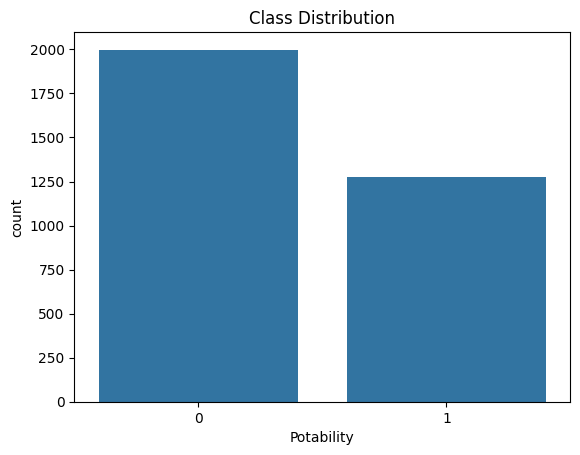

In [35]:
sns.countplot(x='Potability', data=df)
plt.title("Class Distribution")
plt.show()

## **Feature Distributions**

**histograms per feature**

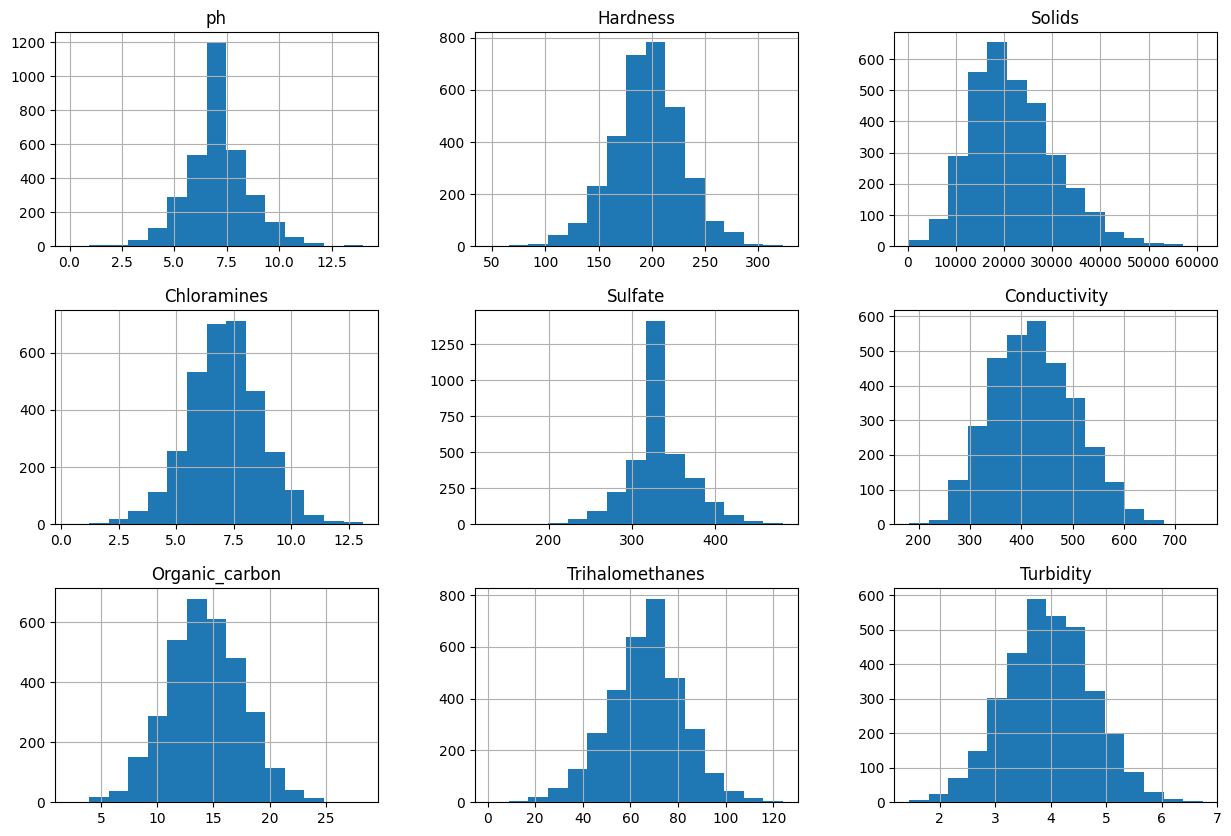

In [40]:
features = df.drop('Potability', axis=1)
features.hist(bins=15, figsize=(15, 10))
plt.show()

**check for Skewed distributions**

In [ ]:
skewed_features = features.apply(lambda x: stats.skew(x.dropna()))
print(skewed_features)

ph                 0.041501
Hardness          -0.039324
Solids             0.621350
Chloramines       -0.012093
Sulfate           -0.022003
Conductivity       0.264369
Organic_carbon     0.025521
Trihalomethanes   -0.086928
Turbidity         -0.007813
dtype: float64


- **potential Log Transform for Hardness**

## **Correlation Analysis**

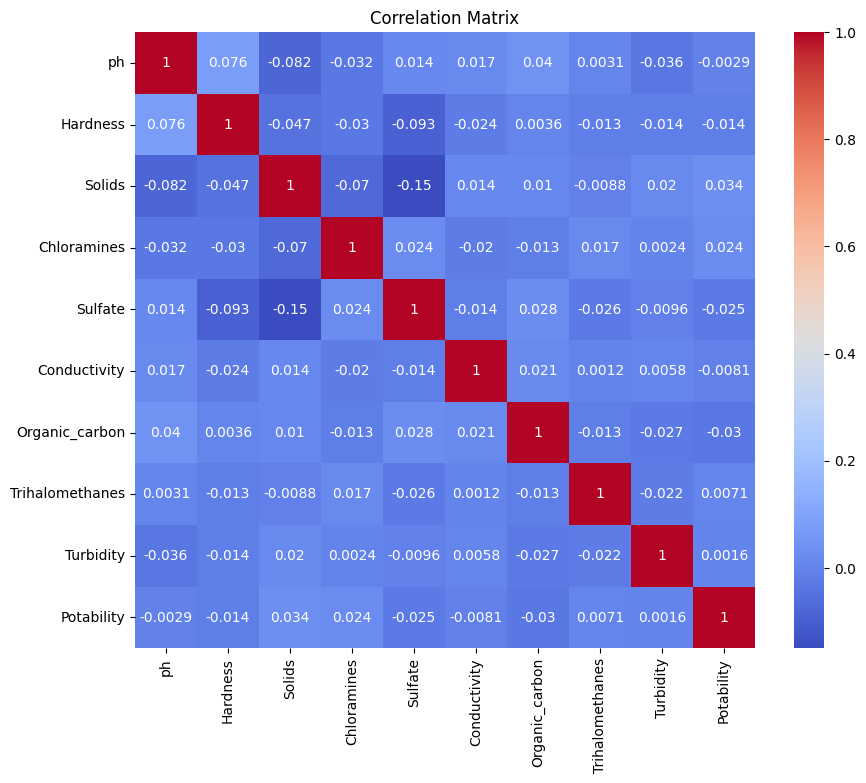

In [42]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

- **That means nonlinear models will perform better than linear ones.**

## **Feature Distribution by Class**

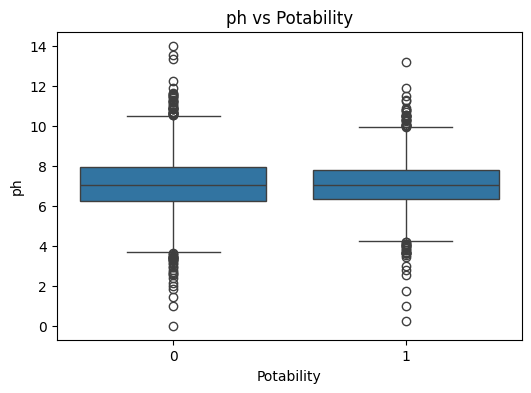

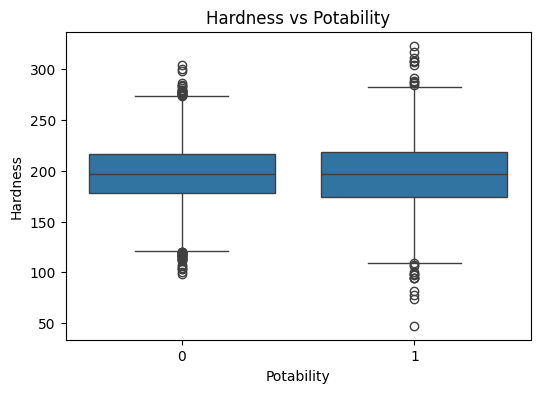

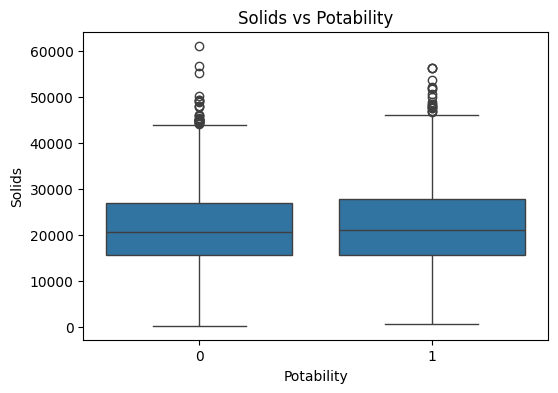

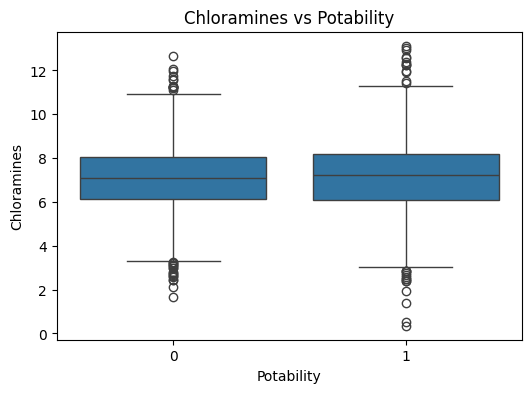

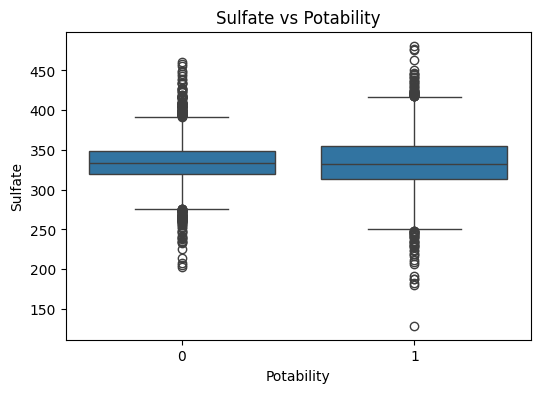

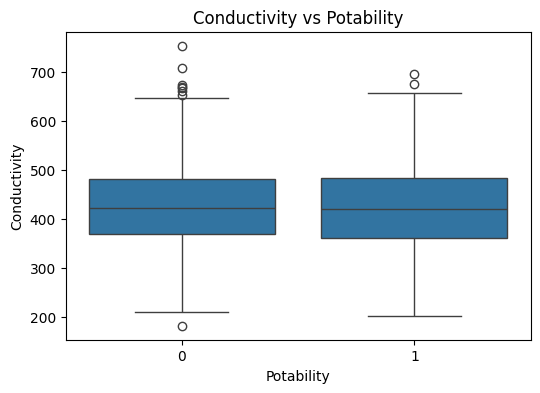

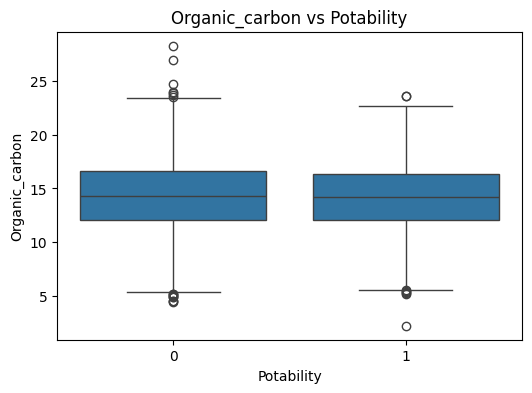

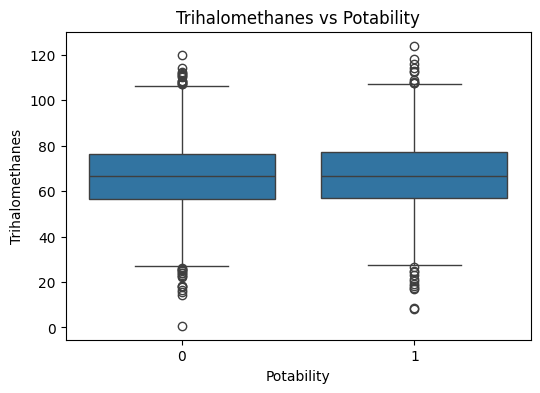

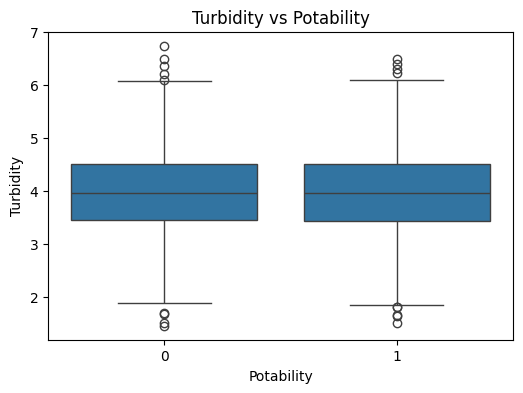

In [43]:
for col in df.columns[:-1]:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Potability', y=col, data=df)
    plt.title(f"{col} vs Potability")
    plt.show()

## **Outlier Detection**

In [46]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

outliers = ((df < (Q1 - 1.5 * IQR)) | 
            (df > (Q3 + 1.5 * IQR))).sum()

print(outliers)

ph                 142
Hardness            83
Solids              47
Chloramines         61
Sulfate            264
Conductivity        11
Organic_carbon      25
Trihalomethanes     54
Turbidity           19
Potability           0
dtype: int64


# **Train/Test Split**

In [ ]:
X = df.drop("Potability", axis=1)
y = df["Potability"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Potability
0    0.609924
1    0.390076
Name: proportion, dtype: float64
Potability
0    0.609756
1    0.390244
Name: proportion, dtype: float64


# **Train** 

## **Gradient Boosting**

In [90]:
gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, rf_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.93      0.85       400
           1       0.84      0.60      0.70       256

    accuracy                           0.80       656
   macro avg       0.81      0.76      0.77       656
weighted avg       0.80      0.80      0.79       656

Confusion Matrix:
[[370  30]
 [102 154]]
ROC AUC: 0.76328125


## **CatBoost**

In [ ]:
cat = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    class_weights=[1, len(y_train[y_train==0])/len(y_train[y_train==1])],
    verbose=0,
    random_state=42
)

cat.fit(X_train, y_train)
cat_pred = cat.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, rf_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.93      0.85       400
           1       0.84      0.60      0.70       256

    accuracy                           0.80       656
   macro avg       0.81      0.76      0.77       656
weighted avg       0.80      0.80      0.79       656

Confusion Matrix:
[[370  30]
 [102 154]]
ROC AUC: 0.76328125


## **LightGBM**

In [ ]:
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42
)

lgbm.fit(X_train, y_train)
lgbm_pred = lgbm.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, rf_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_pred))

[LightGBM] [Info] Number of positive: 1022, number of negative: 1598
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000117 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 2620, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.93      0.85       400
           1       0.84      0.60      0.70       256

    accuracy                           0.80       656
   macro avg       0.81      0.76      0.77       656
weighted avg       0.80      0.80      0.79       656

Confusion Matrix:
[[370  30]
 [102 154]]
ROC AUC: 0.76328125


## **Random Forest**

In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print(" Classification Report:")
print(classification_report(y_test, rf_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_pred))


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.93      0.85       400
           1       0.84      0.60      0.70       256

    accuracy                           0.80       656
   macro avg       0.81      0.76      0.77       656
weighted avg       0.80      0.80      0.79       656

Random Forest Confusion Matrix:
[[370  30]
 [102 154]]
Random Forest ROC AUC: 0.76328125


## **XGBoost**

In [ ]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, rf_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_pred))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.93      0.85       400
           1       0.84      0.60      0.70       256

    accuracy                           0.80       656
   macro avg       0.81      0.76      0.77       656
weighted avg       0.80      0.80      0.79       656

Random Forest Confusion Matrix:
[[370  30]
 [102 154]]
Random Forest ROC AUC: 0.76328125


c:\Users\Informatics\Desktop\master project\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:27:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## **SVM (RBF Kernel)**

In [ ]:
svm = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict(X_test_scaled)

print("Classification Report:")
print(classification_report(y_test, rf_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_pred))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.93      0.85       400
           1       0.84      0.60      0.70       256

    accuracy                           0.80       656
   macro avg       0.81      0.76      0.77       656
weighted avg       0.80      0.80      0.79       656

Random Forest Confusion Matrix:
[[370  30]
 [102 154]]
Random Forest ROC AUC: 0.76328125


## **Extra Trees**

In [ ]:
et = ExtraTreesClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)

et.fit(X_train, y_train)
et_pred = et.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, rf_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_pred))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.93      0.85       400
           1       0.84      0.60      0.70       256

    accuracy                           0.80       656
   macro avg       0.81      0.76      0.77       656
weighted avg       0.80      0.80      0.79       656

Random Forest Confusion Matrix:
[[370  30]
 [102 154]]
Random Forest ROC AUC: 0.76328125


## **K-Nearest Neighbors**

In [68]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)

print("Classification Report:")
print(classification_report(y_test, knn_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, knn_pred))
print("ROC AUC:", roc_auc_score(y_test, knn_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.80      0.70       400
           1       0.46      0.27      0.34       256

    accuracy                           0.59       656
   macro avg       0.54      0.53      0.52       656
weighted avg       0.56      0.59      0.56       656

Confusion Matrix:
[[319  81]
 [188  68]]
ROC AUC: 0.5315624999999999


## **MLP (Neural Network)**

In [81]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64,32),
    max_iter=1000,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)
mlp_pred = mlp.predict(X_test_scaled)

print("Classification Report:")
print(classification_report(y_test, mlp_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, mlp_pred))
print("ROC AUC:", roc_auc_score(y_test, mlp_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.70      0.68       400
           1       0.48      0.42      0.45       256

    accuracy                           0.59       656
   macro avg       0.57      0.56      0.56       656
weighted avg       0.59      0.59      0.59       656

Confusion Matrix:
[[281 119]
 [148 108]]
ROC AUC: 0.5621875000000001


# **Train with hyperparameter tuning**

## **Gradient Boosting Tuning**

In [86]:
gb = GradientBoostingClassifier(random_state=42)

gb_param_grid = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.7, 0.8, 1.0],
    'min_samples_split': [2, 5, 10]
}

gb_grid = GridSearchCV(
    estimator=gb,
    param_grid=gb_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

gb_grid.fit(X_train, y_train)
print("Best GB params:", gb_grid.best_params_)
print("Best GB ROC-AUC:", gb_grid.best_score_)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best GB params: {'learning_rate': 0.05, 'max_depth': 4, 'min_samples_split': 2, 'n_estimators': 200, 'subsample': 0.7}
Best GB ROC-AUC: 0.8708282892779025


## **LightGBM Tuning**

In [87]:
lgbm = LGBMClassifier(random_state=42)

lgbm_param_grid = {
    'num_leaves': [31, 50, 70],
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

lgbm_grid = GridSearchCV(
    estimator=lgbm,
    param_grid=lgbm_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

lgbm_grid.fit(X_train, y_train)
print("Best LGBM params:", lgbm_grid.best_params_)
print("Best LGBM ROC-AUC:", lgbm_grid.best_score_)

Fitting 5 folds for each of 729 candidates, totalling 3645 fits
[LightGBM] [Info] Number of positive: 1022, number of negative: 1598
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000132 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 2620, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.390076 -> initscore=-0.446991
[LightGBM] [Info] Start training from score -0.446991
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

## **CatBoost Tuning**

In [92]:

train_pool = Pool(X_train, y_train)

cat_cpu = CatBoostClassifier(
    task_type='CPU',   # CPU mode
    random_state=42,
    verbose=0
)

grid = {
    'iterations': [200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5],
    'border_count': [32, 50, 100]
}

cat_cpu.grid_search(grid, X=train_pool, cv=5, partition_random_seed=42)
print("Best CatBoost params:", cat_cpu.get_params())


bestTest = 0.4803307811
bestIteration = 199

0:	loss: 0.4803308	best: 0.4803308 (0)	total: 219ms	remaining: 53.1s

bestTest = 0.4087047596
bestIteration = 194

1:	loss: 0.4087048	best: 0.4087048 (1)	total: 473ms	remaining: 57s

bestTest = 0.3907823718
bestIteration = 185

2:	loss: 0.3907824	best: 0.3907824 (2)	total: 695ms	remaining: 55.6s

bestTest = 0.492524242
bestIteration = 199

3:	loss: 0.4925242	best: 0.3907824 (2)	total: 914ms	remaining: 54.6s

bestTest = 0.4045424828
bestIteration = 199

4:	loss: 0.4045425	best: 0.3907824 (2)	total: 1.13s	remaining: 53.9s

bestTest = 0.3911902748
bestIteration = 148

5:	loss: 0.3911903	best: 0.3907824 (2)	total: 1.34s	remaining: 52.9s

bestTest = 0.4886867784
bestIteration = 199

6:	loss: 0.4886868	best: 0.3907824 (2)	total: 1.54s	remaining: 51.9s

bestTest = 0.410928321
bestIteration = 199

7:	loss: 0.4109283	best: 0.3907824 (2)	total: 1.74s	remaining: 51.2s

bestTest = 0.3923763739
bestIteration = 176

8:	loss: 0.3923764	best: 0.3907824 (2)

## **XGBoost Tuning**

In [93]:
xgb_cpu = XGBClassifier(
    tree_method='hist',  
    predictor='cpu_predictor',
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_param_grid = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=xgb_cpu,
    param_grid=xgb_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

xgb_grid.fit(X_train, y_train)
print("Best XGBoost params:", xgb_grid.best_params_)
print("Best XGBoost ROC-AUC:", xgb_grid.best_score_)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best XGBoost params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.7}
Best XGBoost ROC-AUC: 0.8682319040851297


c:\Users\Informatics\Desktop\master project\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [17:00:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [95]:
best_models = {
    "XGBoost": xgb_grid.best_estimator_,
    "LightGBM": lgbm_grid.best_estimator_,
    "CatBoost": cat_cpu,
    "Gradient Boosting": gb_grid.best_estimator_
}

for name, model in best_models.items():
    pred = model.predict(X_test)
    evaluate_model(name, y_test, pred, model, X_test)


===== XGBoost =====
[[364  36]
 [ 97 159]]
              precision    recall  f1-score   support

           0       0.79      0.91      0.85       400
           1       0.82      0.62      0.71       256

    accuracy                           0.80       656
   macro avg       0.80      0.77      0.78       656
weighted avg       0.80      0.80      0.79       656

ROC-AUC: 0.8836328124999999

===== LightGBM =====
[[368  32]
 [ 90 166]]
              precision    recall  f1-score   support

           0       0.80      0.92      0.86       400
           1       0.84      0.65      0.73       256

    accuracy                           0.81       656
   macro avg       0.82      0.78      0.79       656
weighted avg       0.82      0.81      0.81       656

ROC-AUC: 0.8818359375

===== CatBoost =====
[[368  32]
 [ 98 158]]
              precision    recall  f1-score   support

           0       0.79      0.92      0.85       400
           1       0.83      0.62      0.71       256

## **LightGBM**

In [ ]:
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42
)

lgbm.fit(X_train, y_train)
lgbm_pred = lgbm.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, rf_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_pred))

[LightGBM] [Info] Number of positive: 1022, number of negative: 1598
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000117 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 2620, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.93      0.85       400
           1       0.84      0.60      0.70       256

    accuracy                           0.80       656
   macro avg       0.81      0.76      0.77       656
weighted avg       0.80      0.80      0.79       656

Confusion Matrix:
[[370  30]
 [102 154]]
ROC AUC: 0.76328125
